In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# PROBLEM 4(a)(i)
# Load the dataset
data = pd.read_csv('data/question_4_data.csv')

print("Shape of the dataset:", data.shape)
print("----")
print("Datatypes: \n", data.dtypes)
print("----")
print(data.describe())
print("----")
print("Number of samples: " + str(len(data)))
print("Number of features: " + str(len(data.columns) - 1))  # Exclude the target variable
print("Are there missing values? " + str(data.isnull().values.any()))

Shape of the dataset: (1030, 9)
----
Datatypes: 
 cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object
----
            cement         slag       flyash        water  superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.000000   121.800000          0.000000   
25%     192.375000     0.000000     0.000000   164.900000          0.000000   
50%     272.900000    22.000000     0.000000   185.000000          6.400000   
75%     350.000000   142.950000   118.300000   192.000000         10.200000   
max     540.000000   359.400000   200.100000   

Mean:  35.817961165048544
Standard Deviation:  16.705741961912512


'\n - This distribution is skewed to the right, with a long tail towards higher values.\n - Most of the data is to the left (between 10 and 40 MPa).\n - The mean and standard deviation are reported below (35.8 and 16.7, respectively).\n'

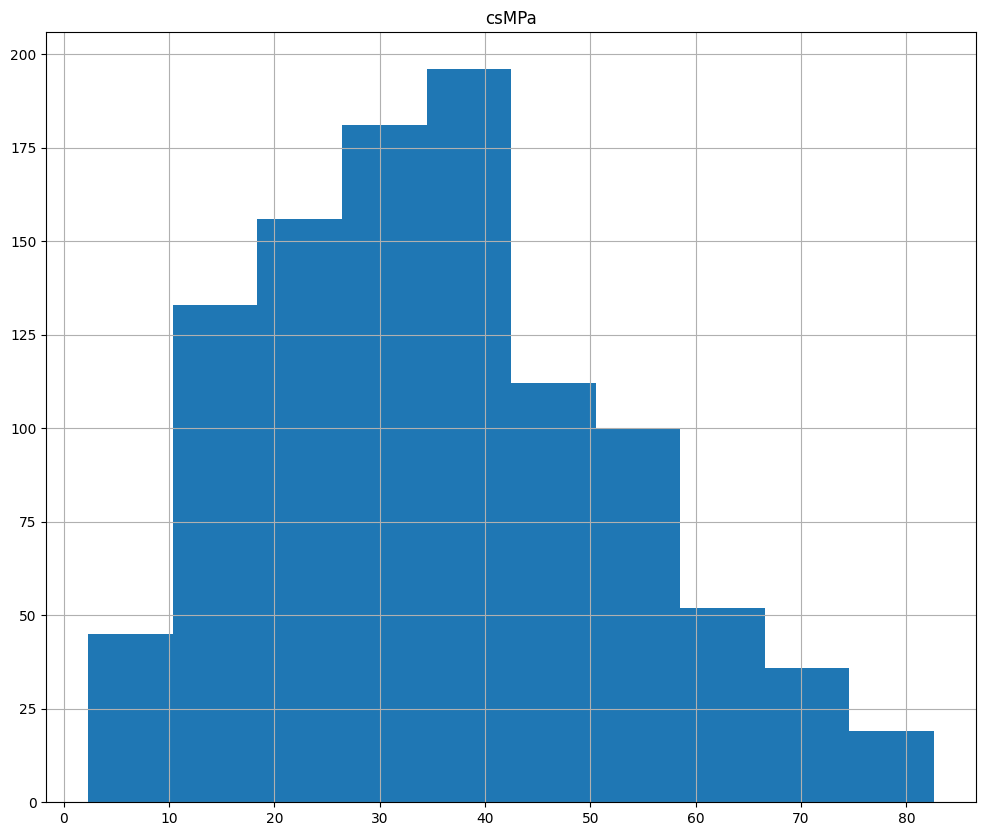

In [4]:
data.hist(column='csMPa', figsize=(12, 10))
mean_value = data['csMPa'].mean()
std_value = data['csMPa'].std()
print("Mean: ", mean_value)
print("Standard Deviation: ", std_value)
"""
 - This distribution is skewed to the right, with a long tail towards higher values.
 - Most of the data is to the left (between 10 and 40 MPa).
 - The mean and standard deviation are reported below (35.8 and 16.7, respectively).
"""

'\n - Slag, superplasticizer, flyash, and age are heavily skewed to the right and contain many zeroes.\n - This might be the case because these are "optional" add-ons to the concrete mixes and are not \n  - as commonly-used or as fundamental/necessary as the other ingredients.\n'

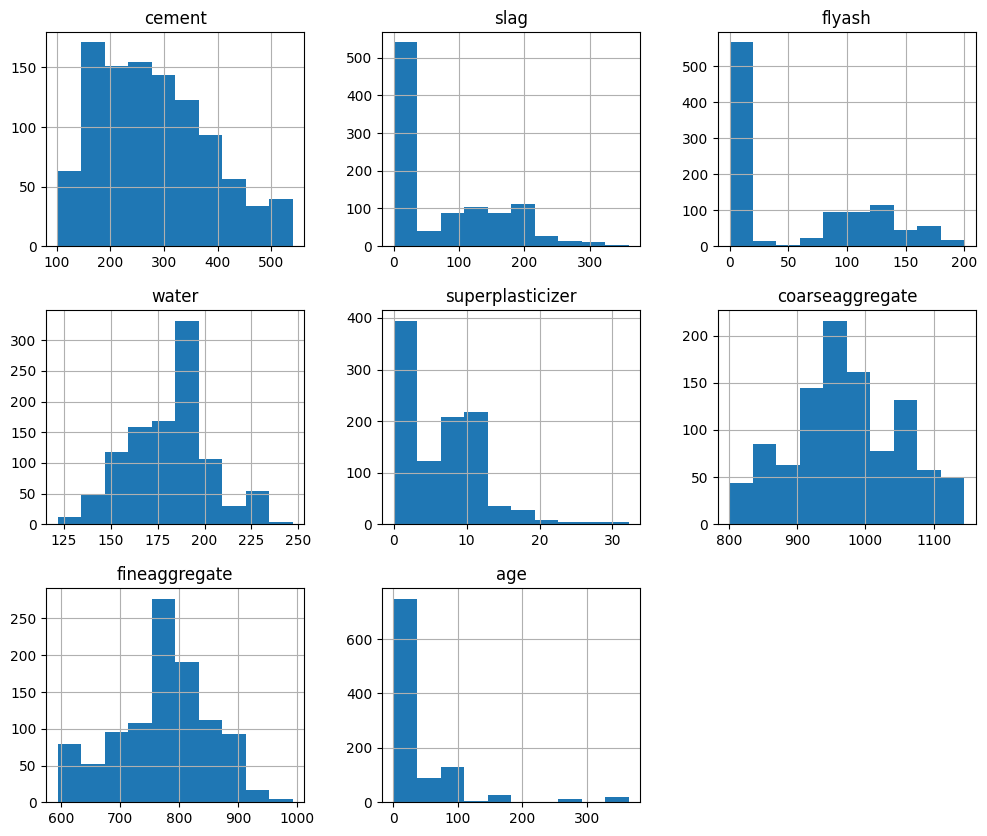

In [5]:
new_cols = data.columns[:-1] # exclude the target variable concrete strength
data.hist(column=new_cols, figsize=(12, 10))

"""
 - Slag, superplasticizer, flyash, and age are heavily skewed to the right and contain many zeroes.
 - This might be the case because these are "optional" add-ons to the concrete mixes and are not 
  - as commonly-used or as fundamental/necessary as the other ingredients.
"""

Pearson correlation between csMPa and cement: 0.4978
Pearson correlation between csMPa and slag: 0.1348
Pearson correlation between csMPa and flyash: -0.1058
Pearson correlation between csMPa and water: -0.2896
Pearson correlation between csMPa and superplasticizer: 0.3661
Pearson correlation between csMPa and coarseaggregate: -0.1649
Pearson correlation between csMPa and fineaggregate: -0.1672
Pearson correlation between csMPa and age: 0.3289


'\n - Cement amount is most positively correlated with strength.\n - Water amount is most negatively correlated with strength.\n - These relationships make sense because cement makes concrete stronger and harder, and water makes it \n  - weaker because the mixture becomes looser, wetter, and more moist.\n'

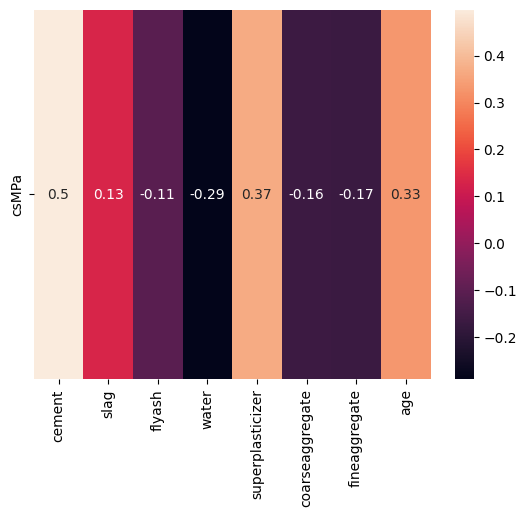

In [6]:
import math

# Pearson Correlation Matrix Calculation
pearson_coeffs = []
for col in data.columns[:-1]:  # Exclude the target variable
    a = np.corrcoef(data[col], data['csMPa'])[0, 1]
    pearson_coeffs.append(a)
    print(f"Pearson correlation between csMPa and {col}: {a:.4f}")

pearson_coeffs = np.array(pearson_coeffs).reshape(1, -1)  # Reshape for heatmap
sns.heatmap(pearson_coeffs, annot=True, xticklabels=data.columns[:-1], yticklabels=['csMPa'])

"""
 - Cement amount is most positively correlated with strength.
 - Water amount is most negatively correlated with strength.
 - These relationships make sense because cement makes concrete stronger and harder, and water makes it 
  - weaker because the mixture becomes looser, wetter, and more moist.
"""

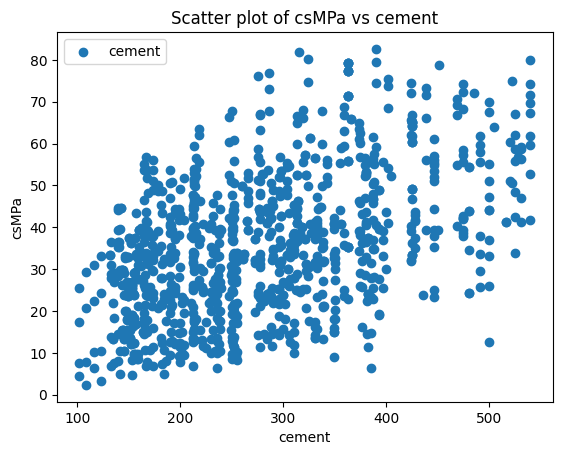

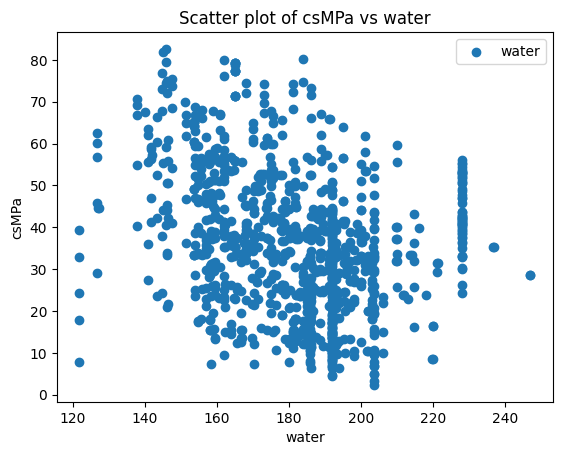

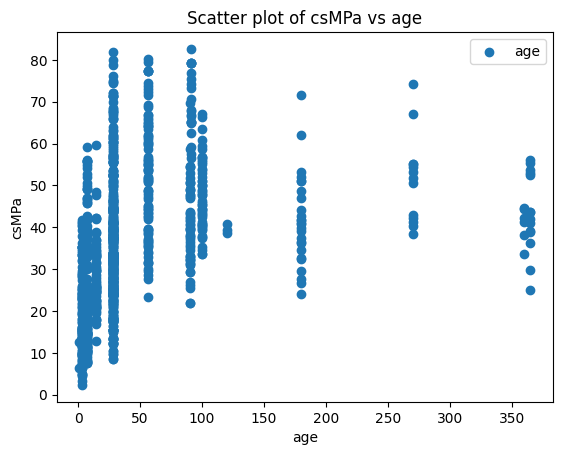

'\n- The relationships appear nonlinear, but there are positive correlations, and a linear relationship\n     - might be a reasonable approximation for these cases.\n'

In [7]:
for col in ['cement', 'water', 'age']:  # Exclude the target variable
    plt.scatter(data[col], data['csMPa'], label=col)
    plt.xlabel(col)
    plt.ylabel('csMPa')
    plt.title(f'Scatter plot of csMPa vs {col}')
    plt.legend()
    plt.show()

"""
- The relationships appear nonlinear, but there are positive correlations, and a linear relationship
     - might be a reasonable approximation for these cases.
"""


In [8]:
# randomly split the data into 80% training and 20% testing sets
np.random.seed(42) 

training_data = data.sample(frac=0.8)  # Sample 80% of the data for training   
    # Note that this uses the "global seed" that we set as 42 above
    # This helps with reproducibility
    
testing_data = data.drop(training_data.index)  # Use the remaining 20% for testing
print("Number of samples in training set:", training_data.shape[0])
print("Number of samples in testing set:", testing_data.shape[0])

Number of samples in training set: 824
Number of samples in testing set: 206


In [9]:
"""Why standardize the data?
Fitting linear regression directly on the raw features is problematic because the "slope"
for each feature's linear relationship will be much different from the others.
 - This means that it will be very difficult to do gradient descent due to the large
    differences in the scales of the slopes.
 - Standardizing the data brings these slopes much closer together than if they are
    left in their raw form, and this also allows for interpreting which features cause
    the most change easier (because they are all normalized).
"""

'Why standardize the data?\nFitting linear regression directly on the raw features is problematic because the "slope"\nfor each feature\'s linear relationship will be much different from the others.\n - This means that it will be very difficult to do gradient descent due to the large\n    differences in the scales of the slopes.\n - Standardizing the data brings these slopes much closer together than if they are\n    left in their raw form, and this also allows for interpreting which features cause\n    the most change easier (because they are all normalized).\n'

In [10]:
for col in data.columns[:-1]:  # Exclude the target variable
    mean = training_data[col].mean()
    std = training_data[col].std()
    
    training_data[col] = (training_data[col] - mean) / std
    testing_data[col] = (testing_data[col] - mean) / std

print("First 5 rows of the standardized training data:")
print(training_data.head())

"""
It would be incorrect to compute mean and variance on the combined train+test data because our model doesn't 
have (shouldn't have) access to the test data during training. The point of the test data is to 
evaluate whether we're overfitting or not, so using testing statistics makes our model worse 
and more likely to overfit later. 
"""

First 5 rows of the standardized training data:
       cement      slag    flyash     water  superplasticizer  \
31  -0.136386  0.493182 -0.857459  2.174267         -1.045332   
109  0.796535  1.384678 -0.857459 -0.740715          0.859627   
136  1.060187  1.384678 -0.857459 -1.618443          2.567522   
88   0.796535  1.384678 -0.857459 -0.740715          0.859627   
918 -1.304953 -0.861892  1.935831  0.973165          0.268433   

     coarseaggregate  fineaggregate       age  csMPa  
31         -0.511592      -1.315683  5.010859  52.91  
109        -0.350494      -0.257096 -0.600147  55.90  
136        -0.350494      -0.257096 -0.271009  74.50  
88         -0.350494      -0.257096 -0.662839  35.30  
918        -1.881562       1.139548 -0.271009  10.54  


"\nIt would be incorrect to compute mean and variance on the combined train+test data because our model doesn't \nhave (shouldn't have) access to the test data during training. The point of the test data is to \nevaluate whether we're overfitting or not, so using testing statistics makes our model worse \nand more likely to overfit later. \n"

In [11]:
print("\n---- TRAINING DATA STATISTICS: ")
for col in data.columns[:-1]:  # Exclude the target variable
    mean = training_data[col].mean()
    std = training_data[col].std()
    print(f"After standardization, mean of {col}: {training_data[col].mean():.4f}, std of {col}: {training_data[col].std():.4f}")

print("\n---- TESTING DATA STATISTICS: ")

for col in data.columns[:-1]:  # Exclude the target variable
    test_mean = testing_data[col].mean()
    test_std = testing_data[col].std()
    print(f"After standardization, mean of {col} in test set: {test_mean:.4f}, std of {col} in test set: {test_std:.4f}")

"""
The test set statistics are NOT exactly 0 and 1 because to compute the mean and std that we 
used to normalize the dataset, we only used the training data. Therefore, on the training data,
this will cause the new mean and variance to be exactly 0 and 1, but on the test data, the mean
and variance will be close to, but not quite, 0 and 1 (they are approximately, but not exactly
the same as the training data).
"""


---- TRAINING DATA STATISTICS: 
After standardization, mean of cement: 0.0000, std of cement: 1.0000
After standardization, mean of slag: 0.0000, std of slag: 1.0000
After standardization, mean of flyash: 0.0000, std of flyash: 1.0000
After standardization, mean of water: -0.0000, std of water: 1.0000
After standardization, mean of superplasticizer: -0.0000, std of superplasticizer: 1.0000
After standardization, mean of coarseaggregate: -0.0000, std of coarseaggregate: 1.0000
After standardization, mean of fineaggregate: 0.0000, std of fineaggregate: 1.0000
After standardization, mean of age: -0.0000, std of age: 1.0000

---- TESTING DATA STATISTICS: 
After standardization, mean of cement in test set: 0.0505, std of cement in test set: 1.0471
After standardization, mean of slag in test set: 0.0824, std of slag in test set: 1.1222
After standardization, mean of flyash in test set: -0.0593, std of flyash in test set: 0.9943
After standardization, mean of water in test set: 0.1463, std o

'\nThe test set statistics are NOT exactly 0 and 1 because to compute the mean and std that we \nused to normalize the dataset, we only used the training data. Therefore, on the training data,\nthis will cause the new mean and variance to be exactly 0 and 1, but on the test data, the mean\nand variance will be close to, but not quite, 0 and 1 (they are approximately, but not exactly\nthe same as the training data).\n'

In [12]:
# LINEAR REGRESSION via normal equations

x_data = training_data.drop(columns=['csMPa'])
# x_data = x_data + np.ones((x_data.shape[0], 1))  # Add a column of 1's for the bias term
x_data.insert(8, 'bias', 1)
y_data = training_data['csMPa']

w_star = np.linalg.inv(x_data.T @ x_data) @ x_data.T @ y_data
print("Optimal weights (w*): \n", w_star)

features_in_order = dict(zip(x_data.columns, w_star))
print("\n---- FEATURES WITH WEIGHT MAGNITUDES: ")
for feature, weight in features_in_order.items():
    print(f"Feature: {feature}, Weight: {weight:.4f}")

Optimal weights (w*): 
 0    13.226065
1     9.488564
2     6.549568
3    -3.115060
4     1.349761
5     1.798775
6     1.841686
7     7.029051
8    35.876566
dtype: float64

---- FEATURES WITH WEIGHT MAGNITUDES: 
Feature: cement, Weight: 13.2261
Feature: slag, Weight: 9.4886
Feature: flyash, Weight: 6.5496
Feature: water, Weight: -3.1151
Feature: superplasticizer, Weight: 1.3498
Feature: coarseaggregate, Weight: 1.7988
Feature: fineaggregate, Weight: 1.8417
Feature: age, Weight: 7.0291
Feature: bias, Weight: 35.8766


In [ ]:
# Report the training and test MSEs
def compute_mse(X, y, w):
    X_arr = X.to_numpy()
    y_arr = y.to_numpy()
    w_arr = np.asarray(w).reshape(-1)
    predictions = X_arr @ w_arr
    mse = np.mean((predictions - y_arr) ** 2)
    return mse

x_test = testing_data.drop(columns=['csMPa'])
x_test.insert(8, 'bias', 1)
y_test = testing_data['csMPa']

x_train = training_data.drop(columns=['csMPa'])
x_train.insert(8, 'bias', 1)
y_train = training_data['csMPa']

train_mse = compute_mse(x_train, y_train, w_star)
test_mse = compute_mse(x_test, y_test, w_star)
print("Training MSE: " + str(train_mse))
print("Test MSE: " + str(test_mse))

"""
Once again, the cement has the largest absolute weight.
This makes sense because cement is the most fundamental component of concrete.
The amount of cement makes the most difference in how strong concrete is. 
"""

Training MSE: 107.79367936030673
Test MSE: 106.86456281099562


In [ ]:
# Polynomial feature expansion
"""
Phi of X produces (8 + 2) choose (2) = 45 features when d = 8 and p = 2.
For p = 3, Phi of X produces (8 + 3) choose (3) = 165 features when d = 8 and p = 3. 
"""

In [ ]:
# Constructing the degree-2 polynomial feature matrix and fitting
# linear regression on the expanded features using the normal equations
d, p = 8, 2
d_plus_p_choose_p = math.comb(d + p, p)
phi_of_x = []
for i in range(d_plus_p_choose_p):
    phi_of_x.append(x_train.to_numpy() ** i)
phi_of_x = np.column_stack(phi_of_x)

# compute the MSE for the polynomial regression model on the training and test sets
y_train_pred = phi_of_x @ w_star_poly
mse_train = np.mean((y_train.to_numpy() - y_train_pred) ** 2)

phi_of_x_test = np.hstack(([1].to_numpy(), x_test.to_numpy(), [1].to_numpy(), x_test.to_numpy() ** 2))
y_test_pred = phi_of_x_test @ w_star_poly
mse_test = np.mean((y_test.to_numpy() - y_test_pred) ** 2)

print("MSE for polynomial regression (training set):", mse_train)
print("MSE for polynomial regression (test set):", mse_test)



LinAlgError: Singular matrix

### Problem 5(a)(i)

In [3]:
# import question_5_data/train.csv and question_5_data/test.csv.
train_data = pd.read_csv("data/question_5_data/train.csv")
test_data = pd.read_csv("data/question_5_data/test.csv")

print("Shape of the training dataset:", train_data.shape)
print("Shape of the test dataset:", test_data.shape)

Shape of the training dataset: (8693, 14)
Shape of the test dataset: (4277, 13)


In [7]:
print("Column names in the training dataset:", train_data.columns)
print("---------------------\nData types in the training dataset:\n", train_data.dtypes)

Column names in the training dataset: Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')
---------------------
Data types in the training dataset:
 PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object


In [9]:
# Display the first five rows
print("First five rows of the training dataset:\n", train_data.head())

First five rows of the training dataset:
   PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        Fa

 - 6 features are numerical and the rest (8) are categorical. 
Note that I'm counting the PassengerID as one of the categorical features (it shouldn't make a difference in the model).

### Problem 5(a)(ii)

In [13]:
# report the number and percent of missing values in each column
missing_values_count = train_data.isnull().sum()
total_rows = train_data.shape[0]
missing_values_percent = (missing_values_count / total_rows) * 100

print("Missing values in each column:")
print(missing_values_count)

Missing values in each column:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [12]:
print("\nPercentage of missing values in each column:")
print(missing_values_percent)


Percentage of missing values in each column:
PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64


<BarContainer object of 14 artists>

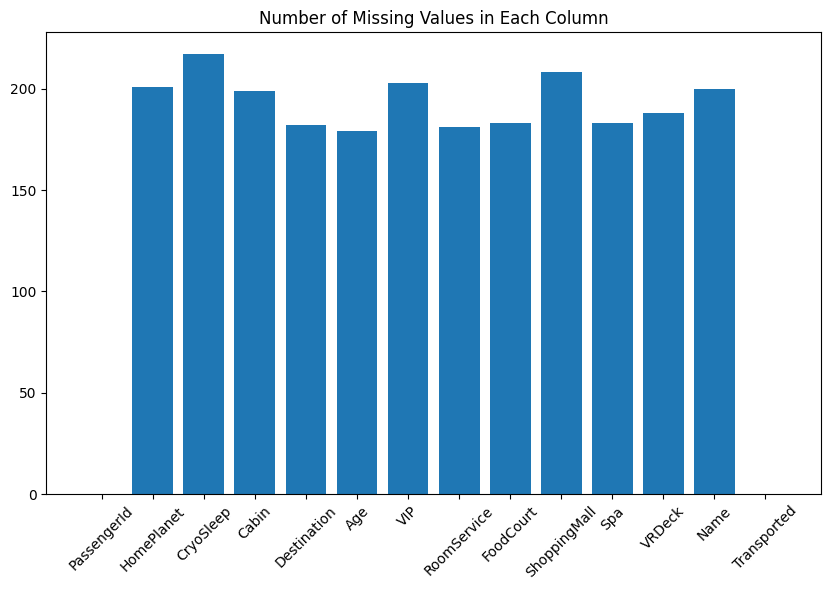

In [17]:
# display the results as a table or bar chart
plt.figure(figsize=(10, 6))
plt.xticks(rotation=45)
plt.title("Number of Missing Values in Each Column")
plt.bar(missing_values_count.index, missing_values_count.values)

 - HomePlanet has the most missing data, followed by ShoppingMall, VIP, Cabin, PassengerID, and Name. 
 - The missing values are spread throughout. 
 - Bar chart of results is shown above.

### Problem 5(a)(iii)

In [ ]:
# split train.csv into 60% train, 20% validation, and 20% test using np.random.seed(42)
np.random.seed(42)

# first split: 80% train+validation, 20% test
all_indices = np.random.permutation(train_data.index)
test_size = int(0.2 * len(train_data))
test_indices = all_indices[:test_size]
train_val_indices = all_indices[test_size:]

# second split: 75%/25% of the remaining 80%, giving 60% train and 20% validation overall
train_size = int(0.75 * len(train_val_indices))
train_indices = train_val_indices[:train_size]
validation_indices = train_val_indices[train_size:]

train_split = train_data.loc[train_indices].copy()
validation_split = train_data.loc[validation_indices].copy()
test_split = train_data.loc[test_indices].copy()

for split_name, split_df in [('Train', train_split), ('Validation', validation_split), ('Test', test_split)]:
    transported_fraction = split_df['Transported'].mean()
    print(f"{split_name} set size: {len(split_df)}")
    print(f"{split_name} transported fraction: {transported_fraction:.4f} ({transported_fraction * 100:.2f}%)")

 - The dataset is roughly balanced because there are about half that were transported and half that were not.

### Problem 5(a)(iv)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

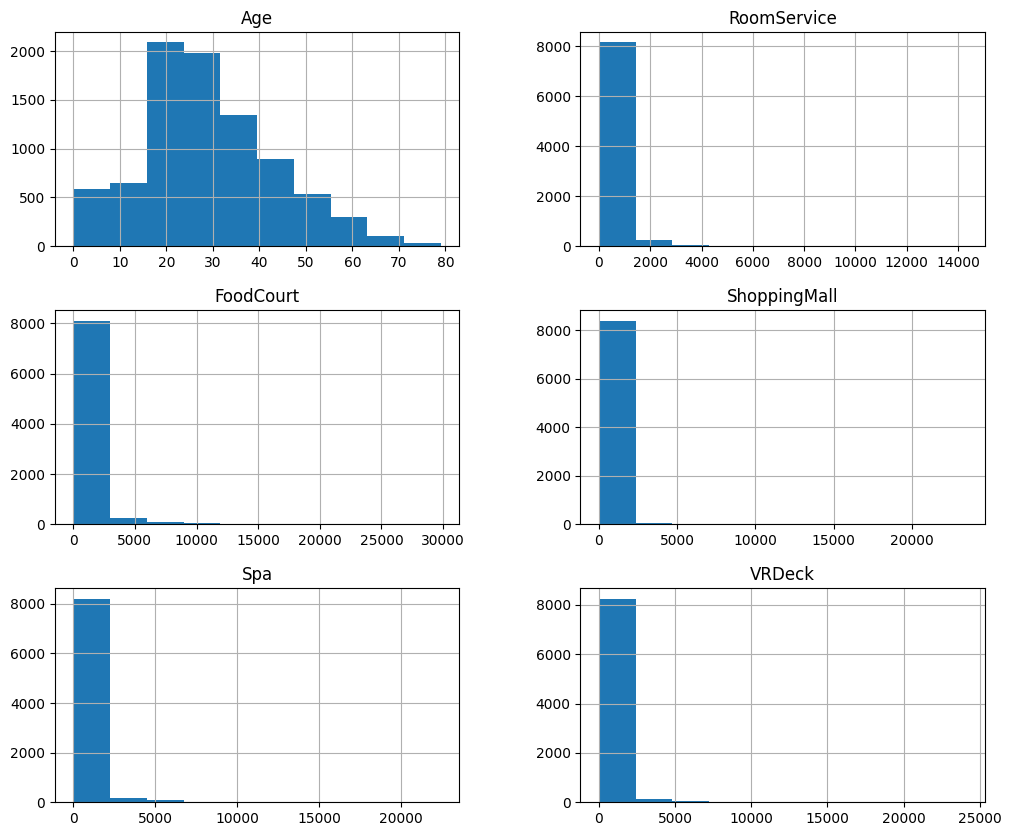

In [32]:
# plot histograms of all numerical features
numerical_cols = train_data.select_dtypes(include=['float64', 'int64']).columns
train_data[numerical_cols].hist(figsize=(12, 10))

 - All of them, except for Age, are heavily right skewed. Age is still right-skewed but to a lesser degree.
 - The fact that most passengers have spending values near zero tells us that most passengers are low-class or middle-class, while there are very few outliers or rich people that have high spending bills.

### Problem 5(a)(v)

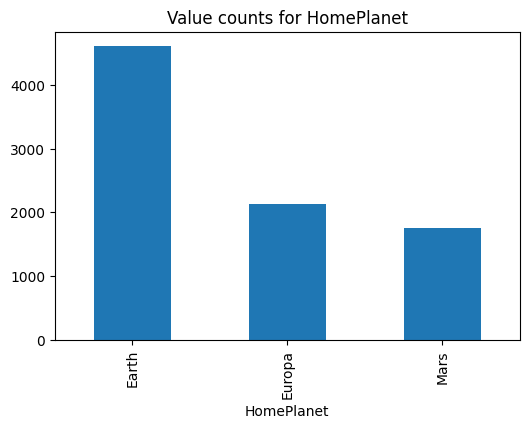

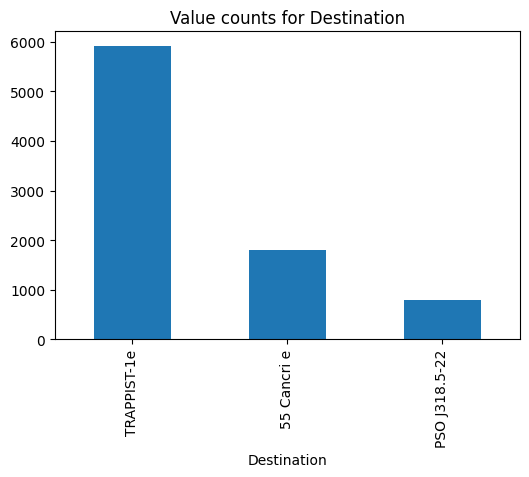

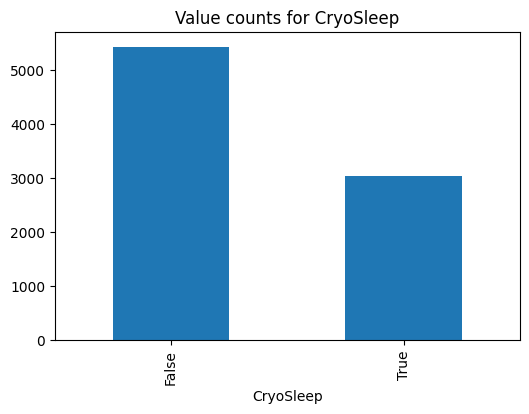

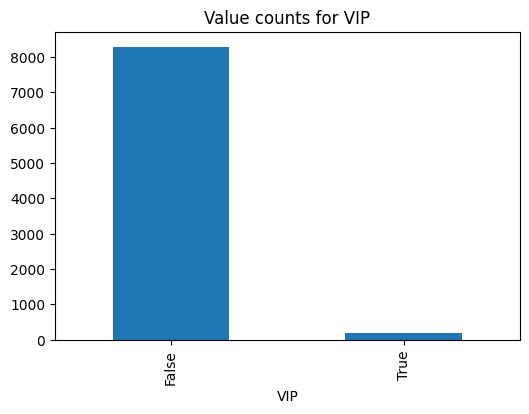

In [48]:
# plot bar chart of HomePlanet, Destination, CryoSleep, and VIP vs how many of their values are NOT null
categorical_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']
for i in categorical_cols:
    plt.figure(figsize=(6, 4))
    train_data[i].value_counts().plot(kind='bar')
    plt.title(f"Value counts for {i}")

In [50]:
# print the fraction of those from each category that were transported
for col in categorical_cols:
    transported_fractions = train_data.groupby(col)['Transported'].mean()
    print(f"-----------\nTransported fractions by {col}:")
    print(transported_fractions)

-----------
Transported fractions by HomePlanet:
HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64
-----------
Transported fractions by Destination:
Destination
55 Cancri e      0.610000
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64
-----------
Transported fractions by CryoSleep:
CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64
-----------
Transported fractions by VIP:
VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64


 - The CryoSleep category seems like the most predictive of the target because it is the most binary and has the largest gap between the transportation rates.

### Problem 5(a)(vi)

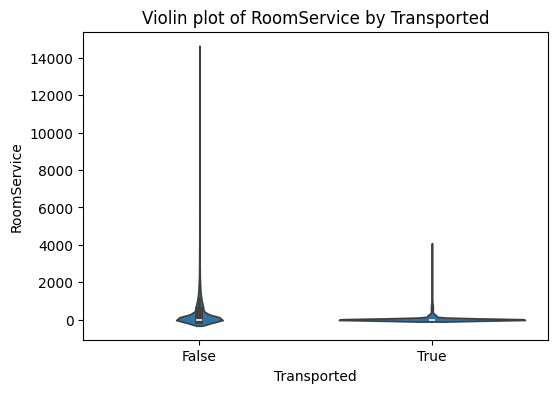

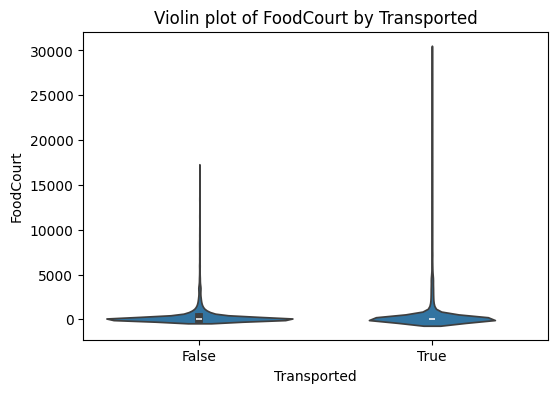

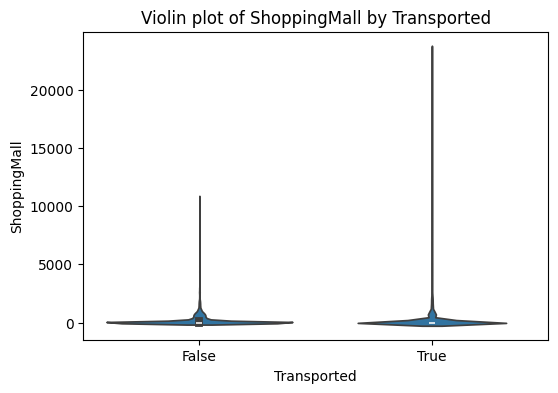

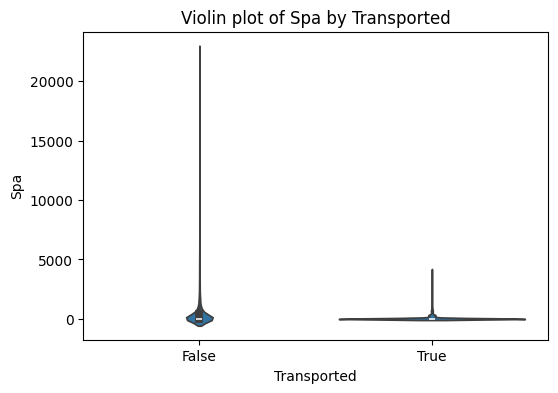

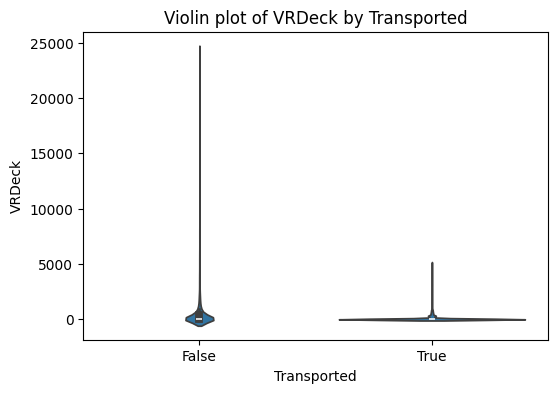

In [60]:
# create violin plot of each spending feature split
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x='Transported', y=col, data=train_data)
    plt.title(f"Violin plot of {col} by Transported")

 - Transported passengers tend to spend less.
 - A hypothesis for this is that because many of the transported passengers were in cryogenic sleep, they could not visit the mall or food court or use the VR technology, so they spent less money by not using those.

### Problem 5(b)(i)

In [52]:
# remove passengerId, Name, and Cabin columns from the training and test datasets
train_data = train_data.drop(columns=['PassengerId', 'Name', 'Cabin'])
test_data = test_data.drop(columns=['PassengerId', 'Name', 'Cabin'])

 - PassengerID and Name are not directly useful for logistic regression because they only serve as indexing tools to "label" a certain passenger and distinguish between different passengers.
 - Cabin is not useful because these don't have any correlation with whether a passenger was transported or not; it, again, is a distinguisher to help categorize different passengers by where they live, and nothing more.

### Problem 5(b)(ii)

In [56]:
# for HomePlanet, Destination, CryoSleep, and VIP, insert the mode into every missing value
for col in categorical_cols:
    mode_value = train_data[col].mode()[0]
    train_data[col] = train_data[col].fillna(mode_value)
print("Finished running this cell.")

Finished running this cell.


### Problem 5(b)(iii)

In [58]:
for col in numerical_cols:
    # compute the mean of the column in the training data
    mean_value = train_data[col].mean()
    train_data[col] = train_data[col].fillna(mean_value)
print("Finished running this cell.")

Finished running this cell.


### Problem 5(b)(iv)

In [65]:
# Convert CryoSleep and VIP to integers (0 and 1) when present
binary_cols = ['CryoSleep', 'VIP']
for col in binary_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].fillna(False).astype(int)

# One-hot encode HomePlanet and Destination when present
encode_cols = [c for c in ['HomePlanet', 'Destination'] if c in train_data.columns]
if encode_cols:
    train_data = pd.get_dummies(train_data, columns=encode_cols, drop_first=True)

# If test_data exists, apply the same encoding and align columns to train_data
if 'test_data' in globals():
    for col in binary_cols:
        if col in test_data.columns:
            test_data[col] = test_data[col].fillna(False).astype(int)
    test_encode_cols = [c for c in ['HomePlanet', 'Destination'] if c in test_data.columns]
    if test_encode_cols:
        test_data = pd.get_dummies(test_data, columns=test_encode_cols, drop_first=True)
    test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

print("Encoded columns:", encode_cols)
print("Finished running this cell.")

KeyError: "None of [Index(['HomePlanet', 'Destination'], dtype='str')] are in the [columns]"